## Trabajo Práctico 1 - Visión por Computadora

Integrantes:
- Matías Guillermo Alfaro
- Rodrigo Hernández
- Gonzalo Cuervo
- Nicolas Alberto Tonnelier
- Marina Andrea Racciatti

### Parte 1
1. Implementar el algoritmo White Patch para librarnos de las diferencias de color de iluminación.

In [1]:
import numpy as np
from PIL import Image


def white_patch(image, percentile=99):
    # me aseguro que estamos en RGB
    image_rgb = image.convert('RGB')
    arr = np.array(image_rgb)
    
    # valores máximos (percentil) de cada canal
    r_max = np.percentile(arr[:, :, 0], percentile)
    g_max = np.percentile(arr[:, :, 1], percentile)
    b_max = np.percentile(arr[:, :, 2], percentile)

    print(f"Valores máximos (percentil {percentile}): R={r_max}, G={g_max}, B={b_max}")
    
    # factor de corrección para cada canal
    r_factor = 255 / r_max if r_max != 0 else 1
    g_factor = 255 / g_max if g_max != 0 else 1
    b_factor = 255 / b_max if b_max != 0 else 1
    
    # crear una nueva imagen para almacenar la imagen corregida
    corrected_image = Image.new('RGB', image.size)
    
    # aplicamos la corrección de color a cada píxel
    for x in range(image.width):
        for y in range(image.height):
            r, g, b = image_rgb.getpixel((x, y))
            r_corrected = min(int(r * r_factor), 255)
            g_corrected = min(int(g * g_factor), 255)
            b_corrected = min(int(b * b_factor), 255)
            corrected_image.putpixel((x, y), (r_corrected, g_corrected, b_corrected))
    
    return corrected_image

2. Mostrar resultados obtenidos y analizar posibles fallas

Valores máximos (percentil 99): R=117.0, G=86.0, B=254.0


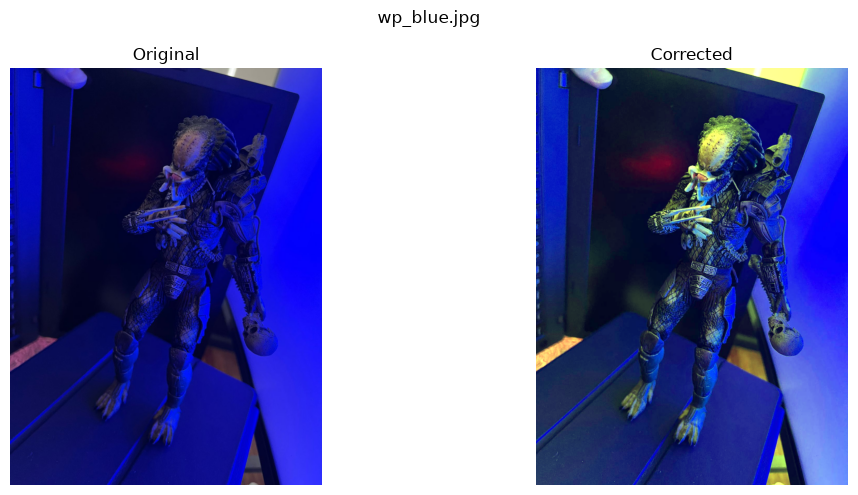

Valores máximos (percentil 99): R=70.0, G=255.0, B=56.0


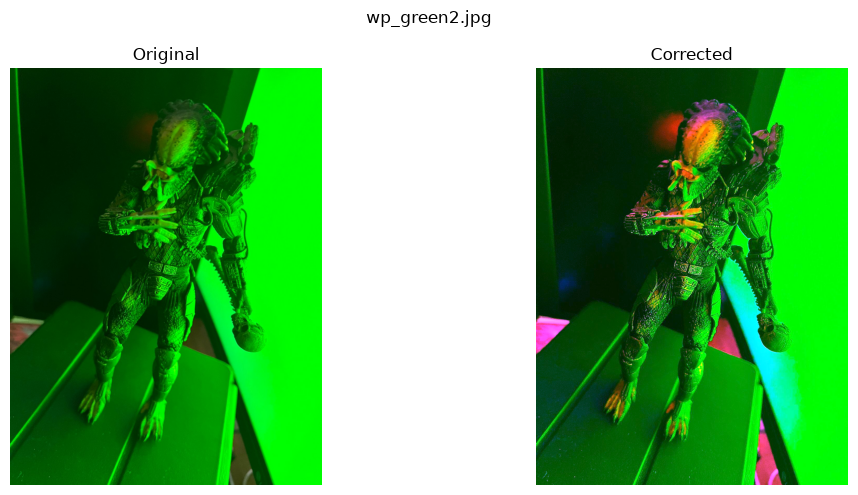

Valores máximos (percentil 99): R=255.0, G=119.0, B=119.0


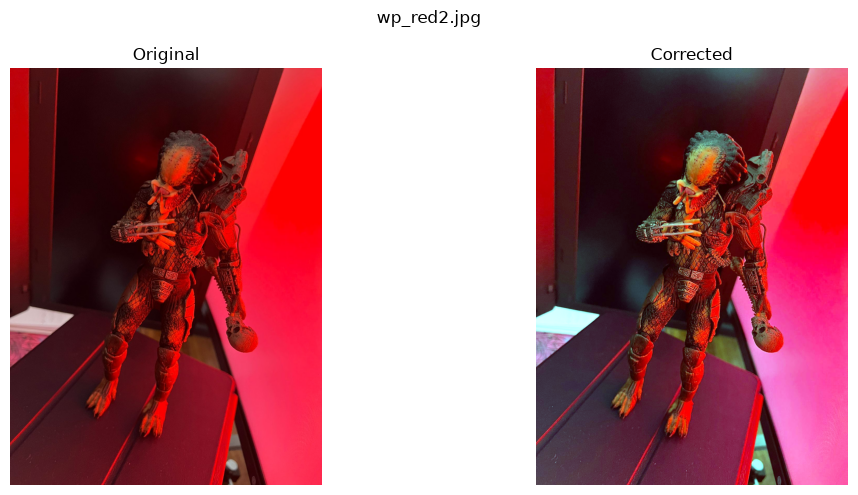

Valores máximos (percentil 99): R=153.0, G=122.0, B=180.0


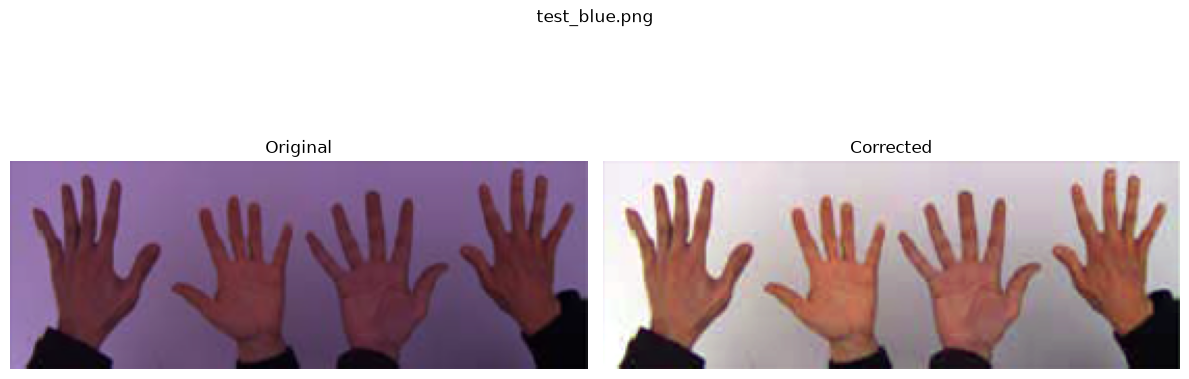

Valores máximos (percentil 99): R=193.0, G=230.0, B=150.0


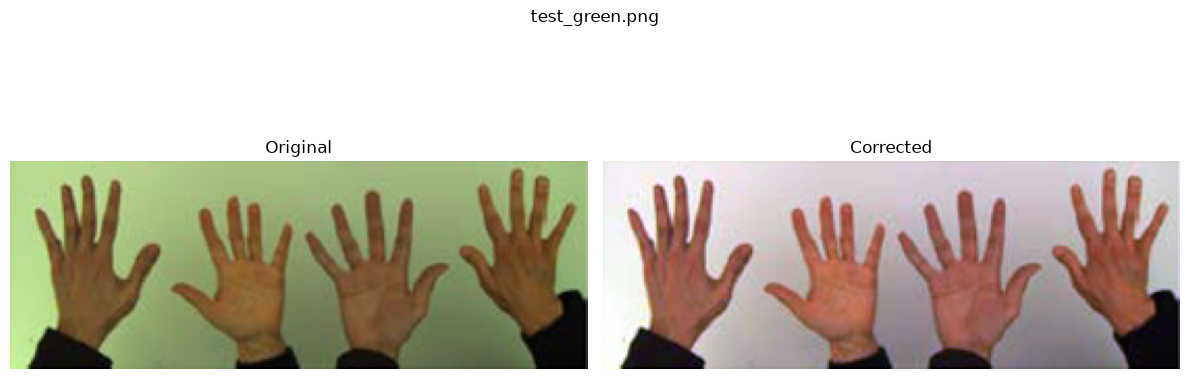

Valores máximos (percentil 99): R=230.0, G=143.0, B=163.0


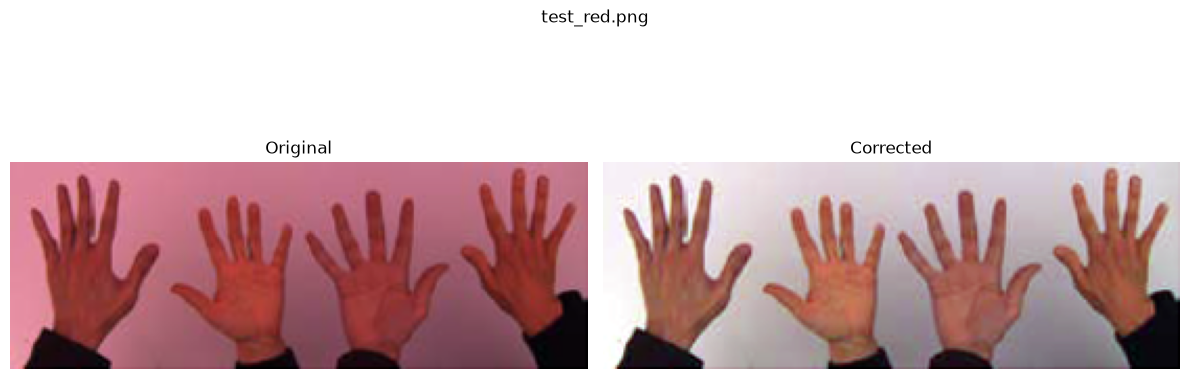

Valores máximos (percentil 99): R=88.0, G=244.0, B=120.0


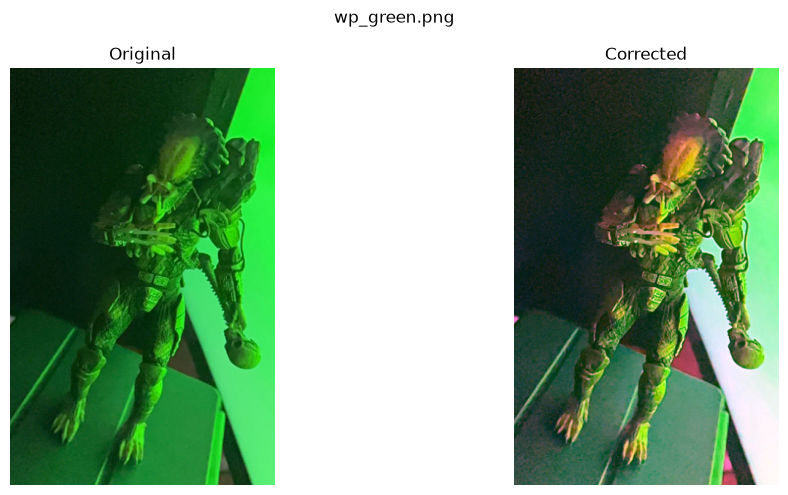

Valores máximos (percentil 99): R=255.0, G=74.0, B=102.0


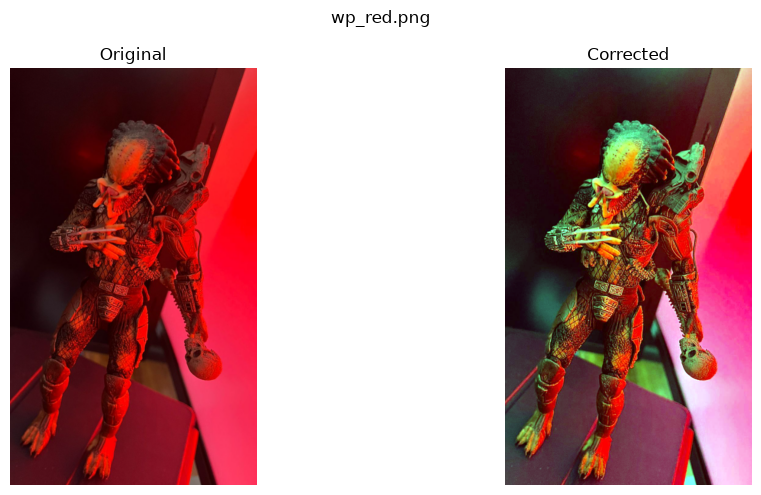

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt

def process_images_in_folder(folder_path):
    folder = Path(folder_path)
    for image_path in list(folder.glob('*.jpg')) + list(folder.glob('*.png')):
        original_image = Image.open(image_path)
        corrected_image = white_patch(original_image)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].imshow(original_image)
        axes[0].set_title('Original')
        axes[0].axis('off')
        axes[1].imshow(corrected_image)
        axes[1].set_title('Corrected')
        axes[1].axis('off')
        fig.suptitle(image_path.name)
        plt.tight_layout()
        plt.show()

process_images_in_folder('white_patch')

Observaciones: antes de aplicar percentil en el algoritmo de white_patch, "wp_red2.jpg" presentaba valores máximos de 255 en todos los canales, con lo que imagen original y corregida eran idénticas. Usar percentil 99 en vez de el valor máximo global solucionó esto.

Por otro lado, pareciera recuperar bastante bien nitidez y color cuando uno de los canales tiene valor máximo bajo, como con "wp_red.png" (G=74.0). Pero si hay dos valores bajos ya le cuesta más, por ejemplo "wp_green2.jpg" (R=70.0, G=255.0, B=56.0).

### Parte 2

1. Para las imagenes `img1_tp.png` y `img2_tp.png`, leerlas con OpenCV en escala de grises y visualizarlas.
2. Elegir una cantidad de bins, graficar sus histogramas, compararlos y analizar si servirian como *features* para clasificacion/deteccion.

Uso 64 bins: agrupa cada 4 niveles de gris, reduce un poco el ruido frente a 256 bins y conserva suficiente detalle para comparar la distribucion de intensidades.

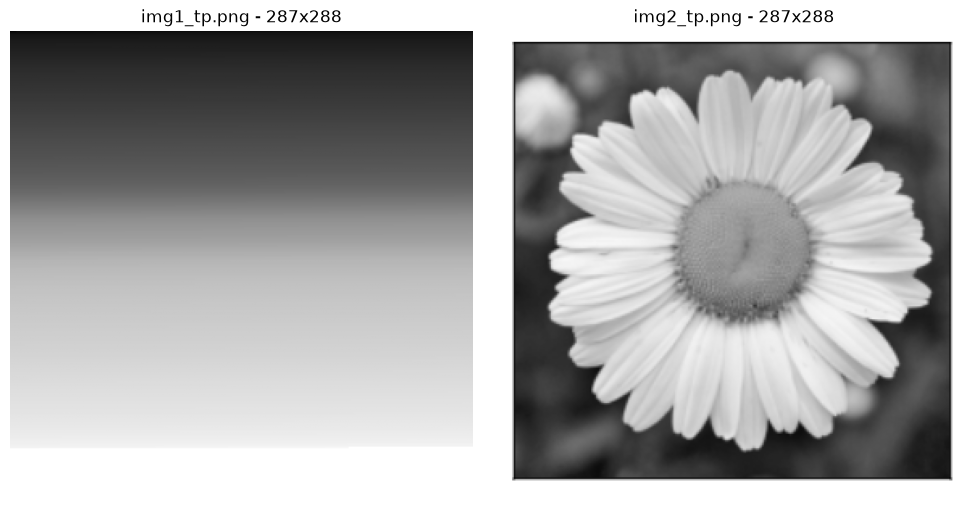

In [3]:
import cv2
import matplotlib.pyplot as plt

img1 = cv2.imread('img1_tp.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('img2_tp.png', cv2.IMREAD_GRAYSCALE)

if img1 is None or img2 is None:
    raise FileNotFoundError('No se pudieron cargar img1_tp.png e img2_tp.png')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, image, title in zip(axes, (img1, img2), ('img1_tp.png', 'img2_tp.png')):
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'{title} - {image.shape[1]}x{image.shape[0]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

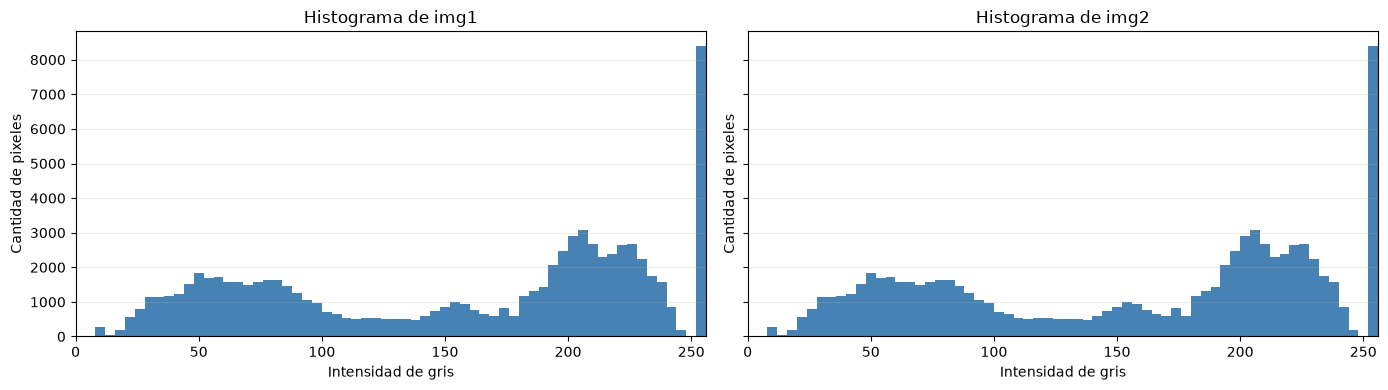

Las imagenes son identicas pixel a pixel? False
Los histogramas son identicos? True
img1: minimo=2, maximo=255, media=154.81, desvio=75.34
img2: minimo=2, maximo=255, media=154.81, desvio=75.34


In [4]:
bins = 64
hist1 = cv2.calcHist([img1], [0], None, [bins], [0, 256]).ravel()
hist2 = cv2.calcHist([img2], [0], None, [bins], [0, 256]).ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, hist, title in zip(axes, (hist1, hist2), ('Histograma de img1', 'Histograma de img2')):
    ax.bar(np.linspace(0, 252, bins), hist, width=4, align='edge', color='steelblue')
    ax.set_title(title)
    ax.set_xlabel('Intensidad de gris')
    ax.set_xlim(0, 256)
    ax.set_ylabel('Cantidad de pixeles')
    ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

print(f'Las imagenes son identicas pixel a pixel? {np.array_equal(img1, img2)}')
print(f'Los histogramas son identicos? {np.array_equal(hist1, hist2)}')
for name, image in [('img1', img1), ('img2', img2)]:
    print(f'{name}: minimo={image.min()}, maximo={image.max()}, media={image.mean():.2f}, desvio={image.std():.2f}')

#### Analisis

Los histogramas son iguales, aunque las imagenes no son identicas pixel a pixel. Por lo tanto, ambas tienen la misma cantidad de pixeles de cada intensidad, pero esos pixeles estan ubicados en posiciones distintas. Un histograma global descarta la informacion espacial: no describe formas, bordes, textura localizada ni la posicion de los objetos.

Como *feature*, un histograma puede ser util para tareas simples en las que el brillo, contraste o distribucion global de intensidades esten asociados a la clase; tambien puede complementar otras caracteristicas. Sin embargo, no seria suficiente por si solo para clasificacion o deteccion: en este ejemplo no logra distinguir las dos imagenes. Para deteccion es especialmente limitado porque no conserva localizacion. Conviene combinarlo con caracteristicas espaciales como HOG, LBP o descriptores locales, o usar representaciones aprendidas por una CNN, segun la tarea.